# Multi-Criteria Alloy Optimization Prototype

This notebook explains and demonstrates the prototype built from the ideas in the following papers:

1. Menou, E., Ramstein, G., Bertrand, E., & Tancret, F. (2016). Multi-objective constrained design of nickel-base superalloys using data mining-and thermodynamics-driven genetic algorithms. Modelling and Simulation in Materials Science and Engineering, 24(5), 055001.

2. Menou, E., Rame, J., Desgranges, C., Ramstein, G., & Tancret, F. (2019). Computational design of a single crystal nickel-based superalloy with improved specific creep endurance at high temperature. Computational Materials Science, 170, 109194.

The goal is to search nickel-base alloy compositions and recover a **Pareto front**: alloys where no other candidate is simultaneously better on every objective.


## Environment Setup

Run these from **inside** the extracted `optimisation_multi-critere/` folder:

```bash
python3 -m venv .venv
source .venv/bin/activate                 # Windows: .venv\Scripts\activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt  # same pinned package versions as the author
python -m pip install -e .                 # install the local alloy_pareto package
```

Then select `.venv` as the notebook kernel in VS Code and run the cells. Built with Python 3.12 (requires Python >= 3.10).

## How It Works

1. **Composition encoding**: each candidate alloy is a dictionary of element wt% values. `Ni` is the balance: `Ni = 100 - sum(alloying elements)`.
2. **Evaluation**: `AlloyEvaluator` computes objective values and constraint penalties. The current implementation uses fast heuristic proxies so the algorithm can run without Thermo-Calc or trained Gaussian-process models.
3. **Objectives**: maximize creep-strength proxy, minimize cost, minimize density, and minimize absolute lattice-misfit proxy.
4. **Constraints**: require enough `Ni`, enough free matrix `Cr`, a target gamma-prime window, limited TCP risk, and limited BTR/weldability risk.
5. **Search algorithms**: `NSGA-II` explores large continuous spaces; `brute_force_search` enumerates coarse grids for small spaces.
6. **Pareto front**: feasible candidates are kept if they are non-dominated across objectives.

## Method Introduction

This prototype compares two ways to find a Pareto front of candidate alloys.

### Brute-force enumeration

Brute force builds a grid of possible compositions and evaluates every grid point. It is simple and useful as a baseline because it does not depend on random initialization. If the grid is fine or the number of elements is large, the number of candidates grows combinatorially and becomes slow very quickly.

Use brute force when:

- the number of alloying elements is small;
- the grid step is coarse, for example 5–10 wt%;
- you want a sanity check for the genetic algorithm;
- you can afford evaluating all candidates.

### NSGA-II genetic algorithm

NSGA-II is a multi-objective evolutionary algorithm. Instead of evaluating every possible alloy, it keeps a population of candidate alloys and improves that population over generations.

One generation works like this:

1. Start with a population of random alloy compositions within allowed bounds.
2. Evaluate each alloy: objectives, constraints, and penalties.
3. Select better candidates using Pareto dominance and feasibility.
4. Create new candidates by crossover, which mixes two parent compositions.
5. Mutate some elements to maintain exploration.
6. Merge parents and children.
7. Sort candidates into non-dominated fronts.
8. Keep diverse candidates using crowding distance.
9. Repeat until the generation limit is reached.

In this notebook, NSGA-II is useful because alloy design is high-dimensional and continuous. It gives an approximate Pareto front much faster than exhaustive enumeration, but it is stochastic: different seeds or settings can give slightly different fronts.

## Data Provenance: Properties and Cost

You can choose between two evaluator modes in the next code cell:

- `DATA_SOURCE = "placeholder"`: original toy mode. Uses synthetic formulas and broad prototype bounds.
- `DATA_SOURCE = "paper"`: uses numerical data extracted from the papers where it is directly usable in this prototype.

### What paper mode currently uses

Paper mode uses:

- Paper [2] Table 3 density model coefficients for `density_g_cm3`.
- Paper [2] Table 4 search bounds for the overlapping elements supported by this prototype: `Al`, `Co`, `Cr`, `Mo`, `Nb`, `Ta`, `Ti`, `W`, with `Ni` as balance.

### What is still placeholder in paper mode

The paper PDFs do **not** contain the full raw creep/property training database or the trained Gaussian-process model. Therefore these remain prototype proxies for now:

- `creep_strength_proxy_mpa`
- `misfit_abs_pct`
- `free_chromium_at_pct_proxy`
- `tcp_risk_proxy`
- `btr_proxy_k`
- `cost_usd_per_kg`

The cost objective still uses `PRICE_USD_PER_KG` in `src/alloy_pareto/evaluation.py`, because the papers report normalized alloy costs for selected examples, not a complete reusable element-price table.

So `DATA_SOURCE = "paper"` is **partly paper-backed**, not a full reproduction of the publications.

In [43]:
import importlib
import inspect
import os

import alloy_pareto
import alloy_pareto.evaluation
import alloy_pareto.nsga2
import alloy_pareto.bruteforce
import alloy_pareto.io

# Reload local modules so notebook kernels pick up code edits without a full restart.
importlib.reload(alloy_pareto.evaluation)
importlib.reload(alloy_pareto.nsga2)
importlib.reload(alloy_pareto.bruteforce)
importlib.reload(alloy_pareto.io)
importlib.reload(alloy_pareto)

from alloy_pareto import AlloyEvaluator, NSGA2Config, brute_force_search, run_nsga2
from alloy_pareto.io import write_csv

DATA_SOURCE = "placeholder"  # choose "placeholder" or "paper"

PROJECT_ROOT = os.getcwd()
if os.path.basename(PROJECT_ROOT) == "notebooks":
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Data source:", DATA_SOURCE)
print("AlloyEvaluator signature:", inspect.signature(AlloyEvaluator))

Project root: /volatile/home/az268520/GitHub/optimisation_multi-critere
Data source: placeholder
AlloyEvaluator signature: (space: 'SearchSpace | None' = None, objectives: 'tuple[Objective, ...] | None' = None, constraints: 'tuple[Constraint, ...] | None' = None, data_source: 'DataSource' = 'placeholder') -> 'None'


## Inspect the Search Space

The decision variables are alloying elements. Nickel is not directly optimized; it is calculated as the remaining balance.

In [44]:
evaluator = AlloyEvaluator(data_source=DATA_SOURCE)
print("Evaluator data source:", evaluator.data_source)
for bound in evaluator.space.bounds:
    print(f'{bound.name:>2}: {bound.lower:4.1f} to {bound.upper:4.1f} wt%')
print(f"Balance element: {evaluator.space.balance_element}, minimum {evaluator.space.balance_minimum:.1f} wt%")

Evaluator data source: placeholder
Al:  1.0 to  6.0 wt%
Ti:  0.0 to  4.0 wt%
Cr: 12.0 to 25.0 wt%
Co:  0.0 to 20.0 wt%
Mo:  0.0 to  8.0 wt%
 W:  0.0 to  8.0 wt%
Nb:  0.0 to  3.0 wt%
Ta:  0.0 to  8.0 wt%
Balance element: Ni, minimum 45.0 wt%


## Evaluate One Candidate

This shows what the optimizer sees for a single alloy: objective values, constraint values, penalties, and feasibility.

Note: for the moment only `density_g_cm3` and the search bounds are paper-backed, so switching `DATA_SOURCE` between `"placeholder"` and `"paper"` changes only those two while the other objectives stay identical for a fixed composition.

In [46]:
candidate = {
    'Al': 6.0, 'Ti': 1.0, 'Cr': 10.0, 'Co': 4.0,
    'Mo': 1.0, 'W': 2.0, 'Nb': 1.0, 'Ta': 8.0,
}
alloy = evaluator.evaluate(candidate)
print('Evaluator data source:', evaluator.data_source)
print('Alloy metadata source:', alloy.metadata['data_source'])
print('Composition:', {k: round(v, 3) for k, v in sorted(alloy.composition.items())})
print('Objectives:', {k: round(v, 3) for k, v in alloy.objectives.items()})
print('Constraints:', {k: round(v, 3) for k, v in alloy.constraints.items()})
print('Penalties:', {k: round(v, 3) for k, v in alloy.penalties.items()})
print('Feasible:', alloy.feasible)

Evaluator data source: placeholder
Alloy metadata source: placeholder
Composition: {'Al': 6.0, 'Co': 4.0, 'Cr': 10.0, 'Mo': 1.0, 'Nb': 1.0, 'Ni': 67.0, 'Ta': 8.0, 'Ti': 1.0, 'W': 2.0}
Objectives: {'creep_strength_proxy_mpa': 667.295, 'cost_usd_per_kg': 30.33, 'density_g_cm3': 7.931, 'misfit_abs_pct': 0.031}
Constraints: {'ni_balance_wt_pct': 67.0, 'free_cr_at_pct_proxy': 10.307, 'gamma_prime_pct_proxy': 75.0, 'tcp_risk_proxy': 1.146, 'btr_proxy_k': 69.0}
Penalties: {'ni_balance_wt_pct': 0.0, 'free_cr_at_pct_proxy': 4.693, 'gamma_prime_pct_proxy': 15.0, 'tcp_risk_proxy': 0.0, 'btr_proxy_k': 0.0}
Feasible: False


## Run NSGA-II

This is the safer default search path. The run below is intentionally small so restart/run-all stays responsive. Increase `population_size` and `generations` only after the notebook is working.

In [47]:
config = NSGA2Config(population_size=24, generations=8, seed=7)
ga_front = run_nsga2(evaluator, config)
ga_front = sorted(ga_front, key=lambda a: a.objectives['cost_usd_per_kg'])
print(f'GA Pareto front size: {len(ga_front)}')
for idx, item in enumerate(ga_front[:8], start=1):
    obj = item.objectives
    comp = item.composition
    print(
        f"{idx:02d} cost={obj['cost_usd_per_kg']:.2f}, "
        f"strength={obj['creep_strength_proxy_mpa']:.1f}, "
        f"density={obj['density_g_cm3']:.2f}, "
        f"Ni={comp['Ni']:.1f}, Cr={comp['Cr']:.1f}, Al={comp['Al']:.1f}, Ti={comp['Ti']:.1f}"
    )

GA Pareto front size: 11
01 cost=18.55, strength=447.7, density=7.82, Ni=71.5, Cr=15.4, Al=4.7, Ti=0.4
02 cost=18.73, strength=532.5, density=7.72, Ni=67.6, Cr=16.0, Al=4.6, Ti=3.3
03 cost=18.95, strength=500.9, density=7.68, Ni=62.6, Cr=18.5, Al=5.2, Ti=0.4
04 cost=19.44, strength=609.5, density=7.56, Ni=50.9, Cr=21.6, Al=4.9, Ti=3.3
05 cost=19.77, strength=465.2, density=7.91, Ni=71.5, Cr=16.0, Al=4.6, Ti=0.4
06 cost=20.38, strength=619.4, density=7.69, Ni=57.1, Cr=15.3, Al=4.7, Ti=3.3
07 cost=20.45, strength=628.3, density=7.51, Ni=45.9, Cr=21.6, Al=4.9, Ti=3.3
08 cost=24.22, strength=611.0, density=7.92, Ni=58.7, Cr=16.6, Al=2.8, Ti=3.9


## Optional Brute-Force Baseline

Paper [2] describes systematic enumeration when the candidate space is tractable. Brute force is disabled by default here because it can make notebook interruption unreliable. Set `RUN_BRUTE_FORCE = True` in the next cell when you want to run it.

In [48]:
RUN_BRUTE_FORCE = True

if RUN_BRUTE_FORCE:
    bf_front = brute_force_search(evaluator, step=12.0, max_evaluations=5_000)
    bf_front = sorted(bf_front, key=lambda a: a.objectives['cost_usd_per_kg'])
    print(f'Brute-force Pareto front size: {len(bf_front)}')
    for idx, item in enumerate(bf_front[:8], start=1):
        obj = item.objectives
        comp = item.composition
        print(
            f"{idx:02d} cost={obj['cost_usd_per_kg']:.2f}, "
            f"strength={obj['creep_strength_proxy_mpa']:.1f}, "
            f"density={obj['density_g_cm3']:.2f}, "
            f"Ni={comp['Ni']:.1f}, Cr={comp['Cr']:.1f}, Al={comp['Al']:.1f}, Ti={comp['Ti']:.1f}"
        )
else:
    bf_front = []
    print('Skipped brute force. Set RUN_BRUTE_FORCE = True to run a coarse exhaustive scan.')

Brute-force Pareto front size: 20
01 cost=13.57, strength=403.0, density=7.43, Ni=69.0, Cr=25.0, Al=6.0, Ti=0.0
02 cost=13.71, strength=404.1, density=7.45, Ni=70.0, Cr=24.0, Al=6.0, Ti=0.0
03 cost=14.68, strength=428.5, density=7.43, Ni=66.0, Cr=25.0, Al=6.0, Ti=0.0
04 cost=14.82, strength=429.6, density=7.44, Ni=67.0, Cr=24.0, Al=6.0, Ti=0.0
05 cost=15.61, strength=469.0, density=7.43, Ni=57.0, Cr=25.0, Al=6.0, Ti=0.0
06 cost=15.75, strength=470.1, density=7.45, Ni=58.0, Cr=24.0, Al=6.0, Ti=0.0
07 cost=16.72, strength=494.5, density=7.43, Ni=54.0, Cr=25.0, Al=6.0, Ti=0.0
08 cost=16.86, strength=495.6, density=7.44, Ni=55.0, Cr=24.0, Al=6.0, Ti=0.0


## Which Method Is Better

Use these criteria:

- **Coverage:** A better method finds a wider range of trade-offs, for example cheap alloys and high-strength alloys.
- **Dominance:** A better method finds candidates that dominate, or improve on, candidates from the other method.
- **Diversity:** A better method avoids returning many nearly identical alloys.
- **Runtime:** A better method gives a useful Pareto front for less computation.
- **Repeatability:** Brute force is deterministic; NSGA-II should be run with several seeds to check stability.
- **Resolution:** Brute force is limited by grid step. NSGA-II can search continuous values, so it may find better intermediate compositions.

Practical recommendation for this prototype: use brute force only as a small/coarse benchmark, then use NSGA-II for larger searches. If NSGA-II repeatedly finds fronts that are as good as or better than the coarse brute-force front, it is the more practical method for this alloy space.

In [49]:
def front_summary(name, front):
    if not front:
        return {
            "method": name,
            "front_size": 0,
            "min_cost": None,
            "max_strength": None,
            "min_density": None,
            "min_misfit": None,
        }
    return {
        "method": name,
        "front_size": len(front),
        "min_cost": min(a.objectives["cost_usd_per_kg"] for a in front),
        "max_strength": max(a.objectives["creep_strength_proxy_mpa"] for a in front),
        "min_density": min(a.objectives["density_g_cm3"] for a in front),
        "min_misfit": min(a.objectives["misfit_abs_pct"] for a in front),
    }

comparison = [
    front_summary("NSGA-II", ga_front),
    front_summary("Brute force", bf_front),
]

for row in comparison:
    print(row)

if bf_front:
    print("\nInterpretation: compare min_cost, max_strength, min_density, min_misfit, and front_size.")
else:
    print("\nBrute force is currently skipped, so only the NSGA-II front is available.")

{'method': 'NSGA-II', 'front_size': 11, 'min_cost': 18.5487792010154, 'max_strength': 657.5103454193475, 'min_density': 7.511191299071473, 'min_misfit': 0.05288244677891031}
{'method': 'Brute force', 'front_size': 20, 'min_cost': 13.57, 'max_strength': 630.96, 'min_density': 7.4266273193704, 'min_misfit': 0.07800000000000003}

Interpretation: compare min_cost, max_strength, min_density, min_misfit, and front_size.


## Visualize the Trade-Off

The cell below plots cost versus creep-strength proxy. If `matplotlib` is unavailable, it prints the same data as a table.

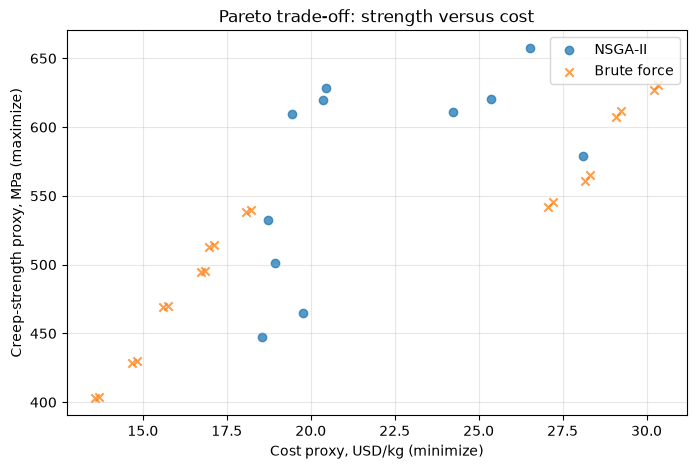

In [50]:
def xy(front):
    return (
        [a.objectives['cost_usd_per_kg'] for a in front],
        [a.objectives['creep_strength_proxy_mpa'] for a in front],
    )

try:
    import matplotlib.pyplot as plt

    ga_x, ga_y = xy(ga_front)
    bf_x, bf_y = xy(bf_front)
    plt.figure(figsize=(8, 5))
    plt.scatter(ga_x, ga_y, label='NSGA-II', alpha=0.75)
    plt.scatter(bf_x, bf_y, label='Brute force', alpha=0.75, marker='x')
    plt.xlabel('Cost proxy, USD/kg (minimize)')
    plt.ylabel('Creep-strength proxy, MPa (maximize)')
    plt.title('Pareto trade-off: strength versus cost')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
except ImportError:
    for label, front in [('NSGA-II', ga_front), ('Brute force', bf_front)]:
        print(label)
        for item in front[:10]:
            print(round(item.objectives['cost_usd_per_kg'], 3), round(item.objectives['creep_strength_proxy_mpa'], 3))

## Export Results

The CSV contains compositions, objectives, constraint values, and penalties. These files can be loaded into spreadsheet software or downstream analysis tools.

In [7]:
results_dir = os.path.join(PROJECT_ROOT, "results")
os.makedirs(results_dir, exist_ok=True)

ga_csv = os.path.join(results_dir, "notebook_ga_front.csv")
bf_csv = os.path.join(results_dir, "notebook_bruteforce_front.csv")
write_csv(ga_csv, ga_front)
write_csv(bf_csv, bf_front)
print(ga_csv)
print(bf_csv)

/volatile/home/az268520/GitHub/optimisation_multi-critere/results/notebook_ga_front.csv
/volatile/home/az268520/GitHub/optimisation_multi-critere/results/notebook_bruteforce_front.csv


## Where to Plug Real Models

The prototype is structured so the optimizer is independent of the science model. To make this production-grade, replace the heuristic functions in `src/alloy_pareto/evaluation.py` with validated calls:

- CALPHAD/Thermo-Calc for phase constitution, gamma-prime fraction, TCP phases, and BTR.
- Gaussian-process or neural-network regressors for creep, yield strength, and oxidation models.
- Updated market/supply-risk models for cost and strategic criticality.

The optimizer only needs objective values plus constraint penalties for each composition.